# 04 — Consolidated analysis

Everything that compares regions to each other, for **both** lines. Nothing here loads a
region for its own sake: it reads the `metrics.csv` files that `03A` and `03B` write in their
step 3, so a change to one region's thresholds means re-running that one block of `03A`, not
this notebook and not all five regions.

Two sections:

1. **Line A (NOAA)** — the cross-region summary, the 24 h fits, and the amplitude-vs-Wilson
   depression relation. This used to live at the tail of `03A` (cells 88–106), which meant
   analysing a single region also re-ran the conclusions for all of them.
2. **Line B (DS0N)** — amplitude estimators compared across DS00–DS09, and the correlations
   between amplitude, area and field.

### What changed from the previous version

- the hardcoded `/home/thomas/Projects/...` path is gone; paths come from `src.config`
  (the old one does not resolve from this working directory at all)
- the local `plot_time_series` that shadowed the `src` one is gone
- the three different DS lists (`00–09` in one cell, a hand-picked five in another, `00–11`
  on disk) are now just `config.DS0N_IDS`
- the silent `nrows=250` truncation is now an explicit, named window
- `fft_amplitude`, `_prepare`, `sine_amplitude` and `mag_amplitude` moved into
  `src/spectra.py` and `src/oscillation.py`, where `03A` and `03B` can use them too

In [1]:
import pathlib
import sys

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import pandas as pd

from src import comparison, config, oscillation, spectra

# Window for the amplitude estimators, in hours from each series' first frame.
# (0, 50) is about two 24 h cycles — the minimum for amplitude, phase and offset to
# separate. None uses the whole series, but then the spot crosses half the disk and the
# mean area stops being comparable between datasets.
WINDOW_H = (0.0, 50.0)
PERIOD_BAND_H = (16.0, 36.0)   # where to look for the "24 h" peak
SAVE = False
REMOVE_POLINOMIAL = True
REMOVE_JUMPS = True      # de-step what the reconstruction leaves behind

print(f'processed NOAA regions : {[p.name for p in config.processed_regions()]}')
print(f'DS0N datasets          : {config.DS0N_IDS}')

processed NOAA regions : ['NOAA_11106_2010-09-16', 'NOAA_11117_2010-10-27', 'NOAA_11363_2011-12-06', 'NOAA_11536_2012-07-31', 'NOAA_13131_2022-10-29']
DS0N datasets          : ['DS00', 'DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08', 'DS09']


---

# Line A — NOAA

## The regions, side by side

Loaded once here and reused by every cell below.

In [2]:
from src.analysis import compute_metrics
from src.loaders import load_noaa_region
from src.post_processing import reconstruct_cubes

all_metrics = {}
for region_dir in config.processed_regions():
    params = config.params_for(region_dir)
    d = load_noaa_region(region_dir, raw_dir=config.RAW_DIR / region_dir.name,
                         **config.loader_kwargs(params))
    if REMOVE_POLINOMIAL:
        new_dop, new_mag= reconstruct_cubes(
            d['cube_dop'], d['cube_mag'], d['timestamps'],
        )
        # Inside the `if`: matches 03A's step 1.5 exactly, so Line A here is the same
        # reconstruction 03A shows, not the pre-reconstruction cubes on disk.
        d['cube_dop'], d['cube_mag'] = new_dop, new_mag
    all_metrics[region_dir.name] = (d, compute_metrics(d))
    print(f'{region_dir.name}: {d["n_t"]} frames, {d["time_h"][-1]:.1f} h')

summary = pd.DataFrame(comparison.region_summary_rows(all_metrics))
summary

2026-08-17 22:39:14 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:170: RuntimeWarning: invalid value encountered in sqrt
  r = 2 * np.sqrt(-p3 / 3)
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:171: RuntimeWarning: invalid value encountered in sqrt
  arg = np.clip((3 * q3) / (2 * p3) * np.sqrt(-3 / p3), -1.0, 1.0)


480 frame(s) matched to 6 coefficient window(s)


/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:289: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t], dtype=np.float64) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


NOAA_11106_2010-09-16: 480 frames, 95.8 h


2026-08-17 22:39:36 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:170: RuntimeWarning: invalid value encountered in sqrt
  r = 2 * np.sqrt(-p3 / 3)
/mnt/shared/Projects/sun_spots_pulsation_review/src/post_processing.py:171: RuntimeWarning: invalid value encountered in sqrt
  arg = np.clip((3 * q3) / (2 * p3) * np.sqrt(-3 / p3), -1.0, 1.0)


...

/mnt/shared/Projects/sun_spots_pulsation_review/src/analysis.py:293: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t], dtype=np.float64) for t in range(n_qsun)]),


NOAA_11536_2012-07-31: 481 frames, 96.0 h


2026-08-17 22:40:34 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days


481 frame(s) matched to 12 coefficient window(s)
NOAA_13131_2022-10-29: 481 frames, 96.0 h


,region,n_frames,span_h,cadence_s,area_umb_mean,area_pen_mean,mean_dop_umb_mean,mean_dop_quiet_mean,mean_mag_umb_mean,mean_mag_hotspot_mean,dop_umb_minus_quiet_mean
0,NOAA_11106_2010-09-16,480,95.8,720.0,217.643805,774.825221,264.240947,-270.718669,10486.655154,9402.378533,534.959616
1,NOAA_11117_2010-10-27,481,96.0,720.0,1406.669474,5259.208421,-1453.520448,-313.944042,-8889.697962,-7356.673605,-1139.576406
2,NOAA_11363_2011-12-06,481,96.0,720.0,1305.000000,5352.290188,11510.485389,-320.304550,3659.671285,3551.273726,11830.726065
3,NOAA_11536_2012-07-31,481,96.0,720.0,130.112266,497.461538,2182.341647,-235.074599,14096.360754,12302.418179,2417.416246
4,NOAA_13131_2022-10-29,481,96.0,720.0,1000.355509,4884.667360,-4222.859994,-276.532505,-7657.760999,-6595.959062,-3946.327489


In [3]:
if REMOVE_POLINOMIAL:
    pass
    #all_metrics.pop('NOAA_11363_2011-12-06', None) #this region failed to be analized so its removed in the case of re
    #all_metrics.pop('NOAA_13131_2022-10-29', None) 

## Removing the steps the reconstruction leaves behind

`reconstruct_cubes` inverts HMI's calibration cubic one frame at a time, and among the
three real roots it picks the one nearest the measured value. Nothing ties that choice to
the frame before it, so when a new `hmi.coefficients` row takes over — a new one starts
every 12 h — the choice can land on a different branch and the series steps by the branch
separation: thousands of m/s between adjacent frames.

`spectra.remove_jumps` finds those steps by their slope and subtracts them, using the slope
either side to keep the curve continuous instead of flattening the interval. Steps landing
near a multiple of 12 h are the signature of the coefficient windows — the dashed grey
lines below mark them. Steps anywhere else are something different and worth a look.

**This is conditioning, not a repair.** Each segment keeps whatever branch it was
reconstructed on, so after the first step only *relative* levels mean anything: the
absolute velocity of a later segment is still whatever the wrong branch gave it.

In [4]:
# Every mean series the reconstruction touched. Areas are left out — they come from the
# continuum masks, which cell 3 never rewrote.
JUMP_KEYS = ('mean_dop_umb', 'mean_dop_pen', 'mean_dop_both', 'mean_dop_quiet',
             'mean_mag_umb', 'mean_mag_pen', 'mean_mag_both', 'mean_mag_quiet',
             'mean_mag_hotspot')

pre_jump, jump_tables, rows = {}, [], []
if REMOVE_JUMPS:
    for name, (d, m) in all_metrics.items():
        pre_jump[name] = {}
        for key in JUMP_KEYS:
            # The quiet-sun series come from the untouched qsun cubes and should report no
            # steps at all; running them through anyway is a free check that the filter is
            # not inventing any.
            if key not in m or len(m[key]) != len(d['time_h']):
                continue
            before = m[key].copy()
            pre_jump[name][key] = before
            m[key], jumps = spectra.remove_jumps(d['time_h'], before)
            if jumps.empty:
                continue
            jump_tables.append(jumps.assign(region=name, key=key))
            offsets = jumps['offset'].to_numpy()
            rows.append(dict(
                region=name, key=key, n_jumps=len(jumps),
                largest=np.abs(offsets).max(),
                # Consecutive offsets of opposite sign mean the inversion is flipping back
                # and forth frame to frame rather than settling on a new level. A high
                # fraction here says the series is thrashing, and de-stepping it is not
                # the right description of what is wrong with it.
                alternating=(np.diff(np.sign(offsets)) != 0).mean() if len(offsets) > 1 else 0.0,
                step_before=np.nanmax(np.abs(np.diff(before))),
                step_after=np.nanmax(np.abs(np.diff(m[key]))),
            ))

    if rows:
        jump_table = pd.concat(jump_tables, ignore_index=True)[
            ['region', 'key', 'index', 'time', 'step', 'expected', 'offset']]
        print(pd.DataFrame(rows).to_string(index=False,
                                           float_format=lambda v: f'{v:.2f}'))
        print(f'\n{len(jump_table)} step(s) removed in total. '
              'The full per-step listing is in `jump_table`.')
    else:
        jump_table = pd.DataFrame()
        print('no steps found — nothing to correct')

               region              key  n_jumps   largest  alternating  step_before  step_after
NOAA_11117_2010-10-27     mean_mag_umb        4   1504.07         0.67      1526.38      298.19
NOAA_11117_2010-10-27    mean_mag_both        1    712.02         0.00       725.15      379.14
NOAA_11117_2010-10-27 mean_mag_hotspot        1   1243.77         0.00      1268.95      407.36
NOAA_11363_2011-12-06     mean_dop_umb       14 115264.66         0.54    115205.69      527.23
NOAA_11363_2011-12-06     mean_dop_pen       21 118642.04         0.70    118547.26     2428.54
NOAA_11363_2011-12-06    mean_dop_both       20 117970.60         0.74    117883.60     2048.95
NOAA_11363_2011-12-06     mean_mag_umb        9  78631.33         0.62     78666.44      341.45
NOAA_11363_2011-12-06     mean_mag_pen       10  41120.15         0.56     41120.09      800.69
NOAA_11363_2011-12-06    mean_mag_both       12  48557.16         0.82     48575.12      735.38
NOAA_11363_2011-12-06 mean_mag_hotspot  

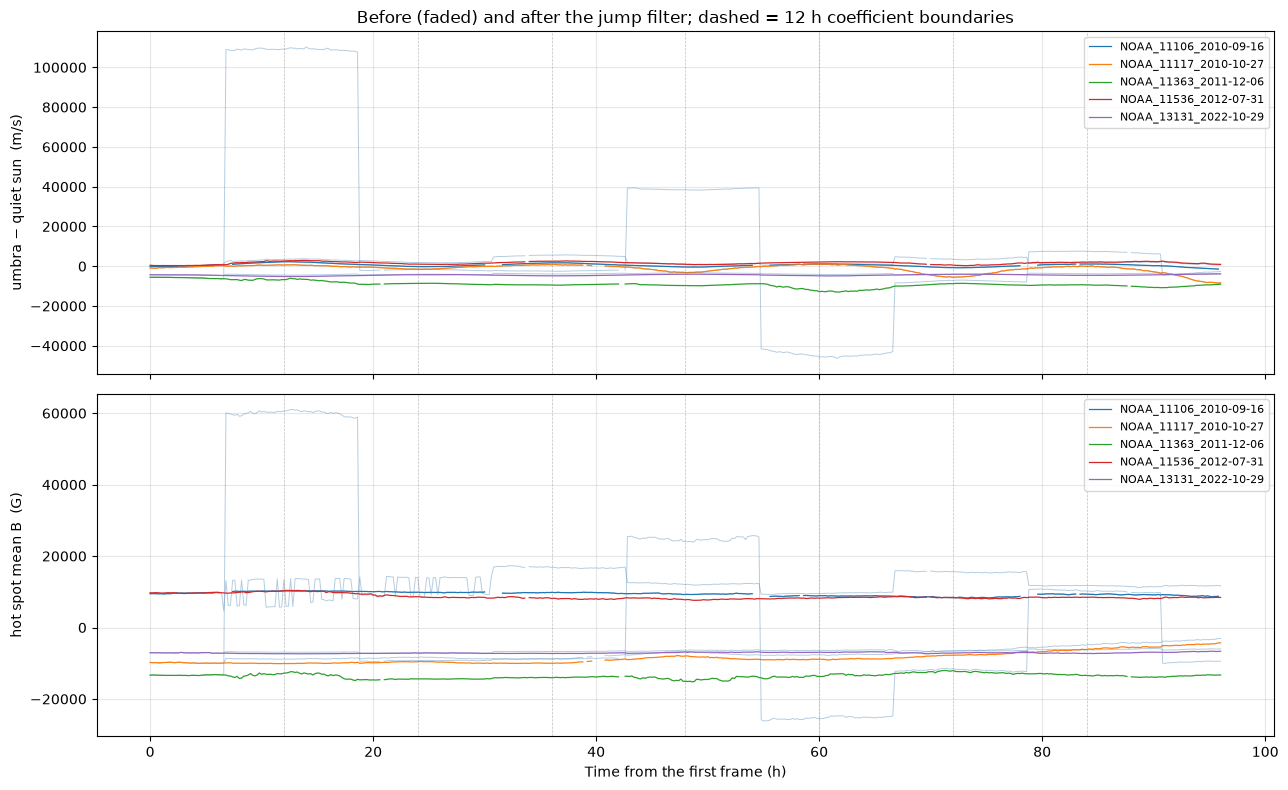

In [5]:
import matplotlib.pyplot as plt

if REMOVE_JUMPS and pre_jump:
    fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    for name, (d, m) in all_metrics.items():
        before = pre_jump[name]
        ax_v.plot(d['time_h'], before['mean_dop_umb'] - before['mean_dop_quiet'],
                  lw=0.7, color='steelblue', alpha=0.4)
        ax_v.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.9, label=name)
        if 'mean_mag_hotspot' in before:
            ax_b.plot(d['time_h'], before['mean_mag_hotspot'],
                      lw=0.7, color='steelblue', alpha=0.4)
            ax_b.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.9, label=name)

    t_max = max(d['time_h'][-1] for d, _ in all_metrics.values())
    for ax in (ax_v, ax_b):
        for boundary in np.arange(12, t_max, 12):
            ax.axvline(boundary, color='grey', ls='--', lw=0.5, alpha=0.5)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    ax_v.set_ylabel('umbra − quiet sun  (m/s)')
    ax_v.set_title('Before (faded) and after the jump filter; dashed = 12 h coefficient '
                   'boundaries')
    ax_b.set_ylabel('hot spot mean B  (G)')
    ax_b.set_xlabel('Time from the first frame (h)')
    plt.tight_layout()
    plt.show()

## Umbral velocity and hot-spot field, all regions on shared axes

The point of overlaying them is the phase: if every region's umbra rises and falls together,
what they share is the observatory, not the Sun.

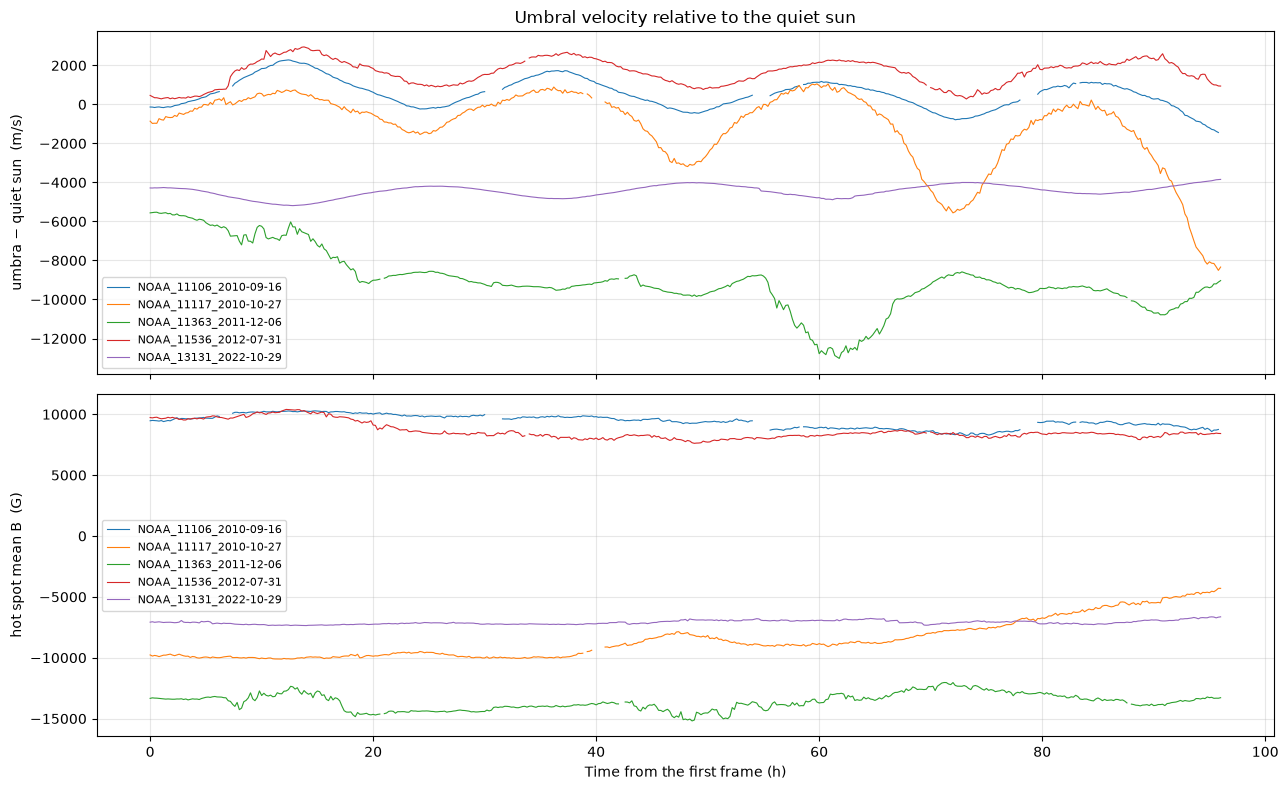

In [6]:
import matplotlib.pyplot as plt

fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for name, (d, m) in all_metrics.items():
    ax_v.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.8, label=name)
    if 'mean_mag_hotspot' in m:
        ax_b.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.8, label=name)

ax_v.set_ylabel('umbra − quiet sun  (m/s)')
ax_v.set_title('Umbral velocity relative to the quiet sun')
ax_b.set_ylabel('hot spot mean B  (G)')
ax_b.set_xlabel('Time from the first frame (h)')
for ax in (ax_v, ax_b):
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## The 24 h fit, per region

`fit_diurnal` is a linear least-squares fit of `c + a·sin(2πt/P) + b·cos(2πt/P)` at a
**fixed** period, giving `amplitude = hypot(a, b)` with a real uncertainty.

Two fits per region, over **identical points**:

- **absolute** umbral velocity
- **umbra − quiet sun**

That pair is the instrumental control. Over the same mask the linear fit of `(umbra − quiet)`
is exactly the fit of umbra minus the fit of quiet, so the ratio of the two amplitudes says
how much of the signal is umbral and how much moved the whole box together. At a 24 h period,
"the whole box together" points at residual SDO orbital velocity rather than at the sunspot.

The windows and the Löptien reference table are in `src/config.py`. NOAA 11117 appears twice
because the table does: 2010-10-27 and 2010-10-28 are one continuous passage in a single
cube, so its two rows are the 0–24 h and 24–48 h stretches and give two independent points.

In [7]:
by_noaa = {config.region_noaa(pathlib.Path(name)): (name, d, m)
           for name, (d, m) in all_metrics.items()}

fit_rows, skipped = [], []
for noaa, date, theta, area_mm2, b_av, z_div, z_press in config.LOPTIEN_TABLE:
    window = config.FIT_WINDOWS.get((noaa, date))
    if noaa not in by_noaa:
        skipped.append(f'NOAA {noaa} {date}: no processed cube')
        continue
    if window is None:
        skipped.append(f'NOAA {noaa} {date}: no entry in config.FIT_WINDOWS')
        continue

    region_name, d, m = by_noaa[noaa]
    time_h = d['time_h']
    v_abs = m['mean_dop_umb']
    v_rel = m['mean_dop_umb'] - m['mean_dop_quiet']
    label = f'NOAA {noaa} {date}'

    # One shared mask for both fits — this is what makes the two amplitude columns a real
    # control rather than two loosely related numbers.
    shared = np.isfinite(v_abs) & np.isfinite(v_rel)

    fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
                                      period_h=config.FIT_PERIOD_H, mask=shared,
                                      label=f'{label} abs')
    fit_rel = oscillation.fit_diurnal(time_h, v_rel, window=window,
                                      period_h=config.FIT_PERIOD_H, mask=shared,
                                      label=f'{label} rel')

    fit_rows.append(dict(label=label, noaa=noaa, date=date, region=region_name,
                         window=window, theta_deg=theta, area_mm2=area_mm2, b_av=b_av,
                         z_div=z_div, z_press=z_press, time_h=time_h,
                         series=v_abs, series_rel=v_rel,
                         fit_abs=fit_abs, fit_rel=fit_rel))

for note in skipped:
    print(f'  skipped  {note}')

print()
header = (f'{"region":22s} {"window":>12s} {"n":>4s} | {"intercept":>10s} '
          f'{"amplitude":>16s} {"t_max":>7s} {"rms":>7s} | {"intercept":>10s} {"amplitude":>16s}')
print(f'{"":22s} {"":>12s} {"":>4s} | {"--- umbra, absolute (m/s) ---":^43s} | '
      f'{"--- umbra - quiet sun (m/s) ---":^29s}')
print(header)
print('-' * len(header))
for row in fit_rows:
    a, r = row['fit_abs'], row['fit_rel']
    t0, t1 = row['window']
    print(f'{row["label"]:22s} {f"{t0:.0f}-{t1:.0f}":>12s} {a["n"]:4d} | '
          f'{a["intercept"]:10.1f} {a["amplitude"]:8.1f} ± {a["sigma_amplitude"]:5.1f} '
          f'{a["t_max"]:7.1f} {a["rms_residual"]:7.1f} | '
          f'{r["intercept"]:10.1f} {r["amplitude"]:8.1f} ± {r["sigma_amplitude"]:5.1f}')

print()
for row in fit_rows:
    a, r = row['fit_abs']['amplitude'], row['fit_rel']['amplitude']
    if np.isfinite(a) and a > 0:
        note = '   <- mostly common to the whole box' if r / a < 0.5 else ''
        print(f'  {row["label"]:22s} umbral fraction of the amplitude: {r / a:.2f}{note}')

  skipped  NOAA 11039 2010-01-01: no processed cube
  skipped  NOAA 11041 2010-01-26: no processed cube

                                         |        --- umbra, absolute (m/s) ---        | --- umbra - quiet sun (m/s) ---
region                       window    n |  intercept        amplitude   t_max     rms |  intercept        amplitude
--------------------------------------------------------------------------------------------------------------------
NOAA 11106 2010-09-16          0-24  116 |      704.9   1124.8 ±  12.5    12.7    96.4 |      945.8   1121.5 ±  12.4
NOAA 11117 2010-10-27          0-24  121 |     -480.8    802.0 ±  22.9    11.2   176.2 |     -163.2    813.1 ±  22.7
NOAA 11117 2010-10-28         24-48  115 |     -764.5   1382.5 ±  57.0    35.4   436.2 |     -448.6   1388.2 ±  57.0
NOAA 11363 2011-12-06          0-24  120 |    -7393.4   1268.2 ± 103.5     6.8   787.2 |    -7117.1   1255.8 ± 102.6
NOAA 11536 2012-07-31          0-24  121 |     1431.0   1194.5 ±  27.6  

/tmp/ipykernel_486358/3640204287.py:24: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
/tmp/ipykernel_486358/3640204287.py:27: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 rel]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_rel = oscillation.fit_diurnal(time_h, v_rel, window=window,
/tmp/ipykernel_486358/3640204287.py:24: UserWarning: fit_diurnal [NOAA 11117 2010-10-27 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = oscillation.fit_diurnal(time_h, v_abs, window=window,
/tmp/ipyke

Saved next to the cubes, one row per table entry, so the numbers can be re-read without
re-running any of this.

In [8]:
fit_csv = config.PROCESSED_DIR / 'diurnal_fits.csv'
pd.DataFrame([{
    'label': row['label'], 'noaa': row['noaa'], 'date': row['date'],
    'region': row['region'], 'period_h': config.FIT_PERIOD_H,
    'window_start_h': row['window'][0], 'window_end_h': row['window'][1],
    'n_points': row['fit_abs']['n'],
    'theta_deg': row['theta_deg'], 'area_mm2': row['area_mm2'], 'b_av_G': row['b_av'],
    'z_div_km': row['z_div'], 'z_press_km': row['z_press'],
    **{f'{k}_abs': row['fit_abs'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
    **{f'{k}_rel': row['fit_rel'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
} for row in fit_rows]).to_csv(fit_csv, index=False, float_format='%.4f')
print(f'Fits saved → {fit_csv}  ({len(fit_rows)} rows)')

Fits saved → /mnt/shared/Projects/sun_spots_pulsation_review/data/processed/diurnal_fits.csv  (6 rows)


## The fits themselves

Always look at these before reading anything off the scatter below: a fit with a large `rms`
or a window covering barely one period will still return a confident-looking amplitude.

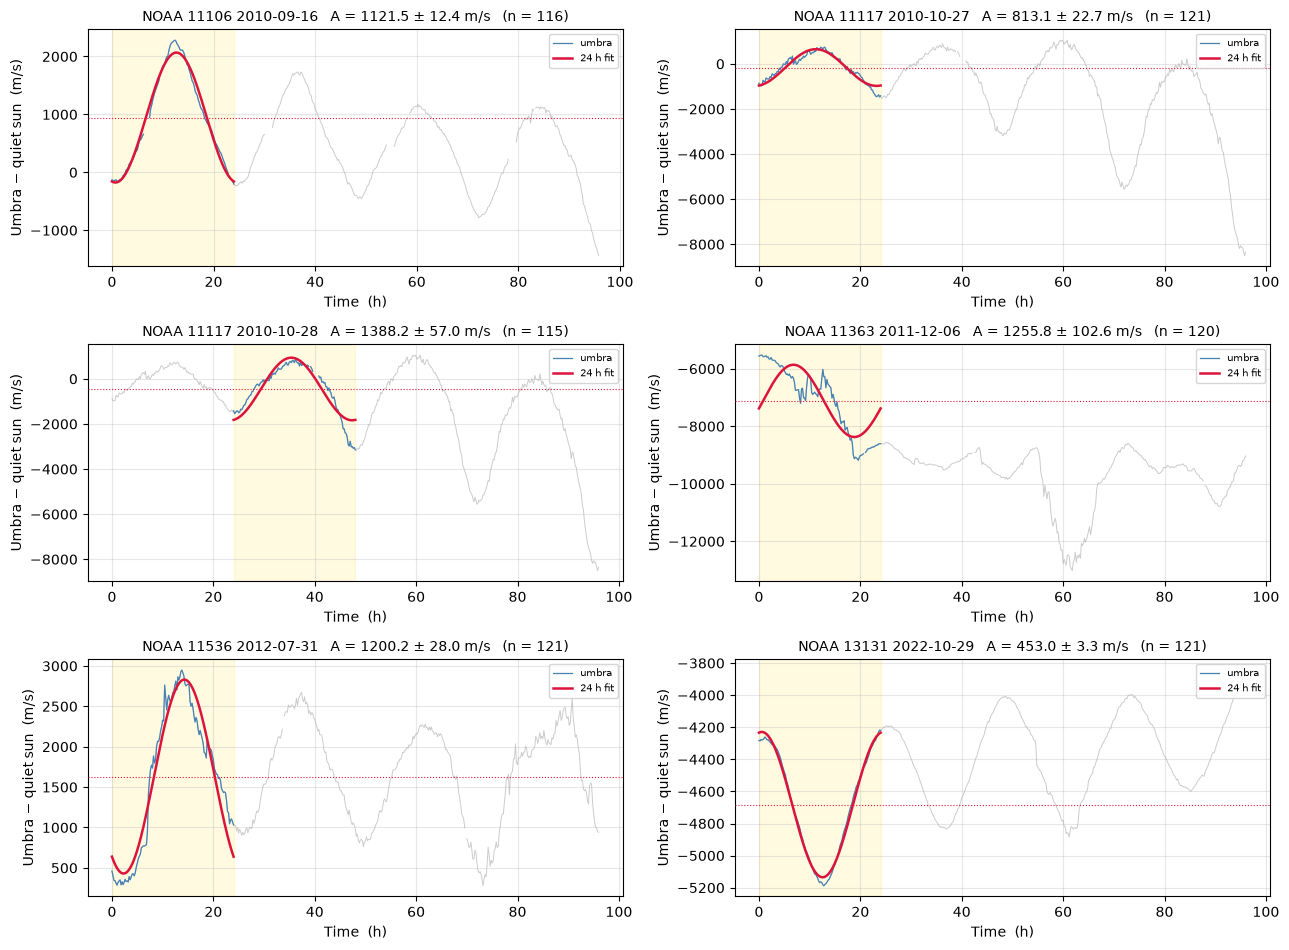

In [9]:
comparison.plot_diurnal_fits(fit_rows, series_key='fit_rel', save=SAVE,
                             plots_dir=config.PROCESSED_DIR / 'plots')

## Amplitude vs Wilson depression

The scientific payoff of line A: the fitted 24 h umbral Doppler amplitude against the Wilson
depression Löptien et al. measured with Hinode by a completely independent method.



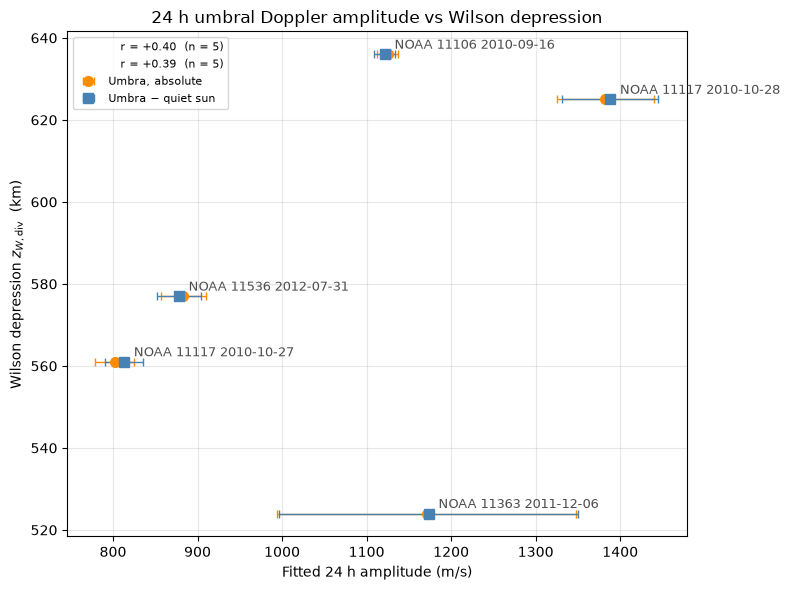

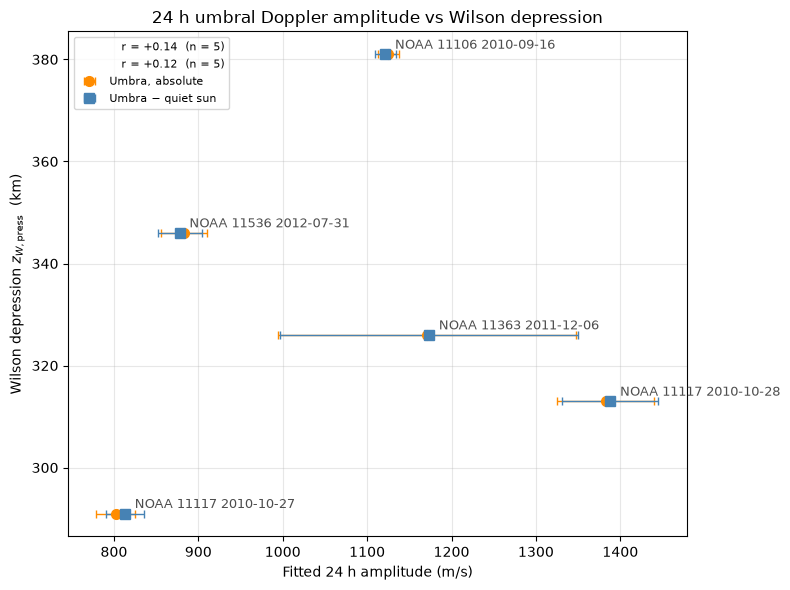

In [51]:
plots_dir = config.PROCESSED_DIR / 'plots'
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_div', save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_press', save=SAVE, plots_dir=plots_dir)

### Amplitude vs area

Plotting amplitude against **1/area** described the sample better than normalising the
amplitude *by* area, which over-fitted it. Both are here so the difference is visible rather
than remembered.

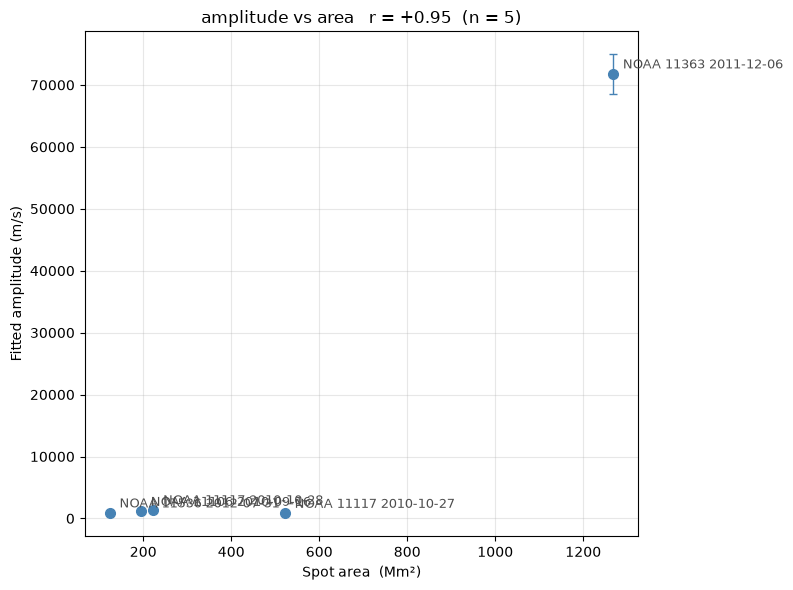

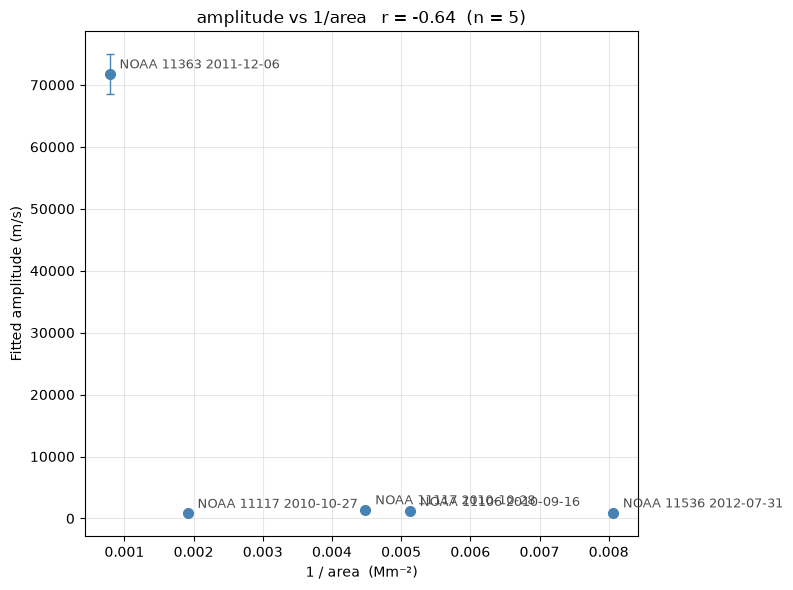

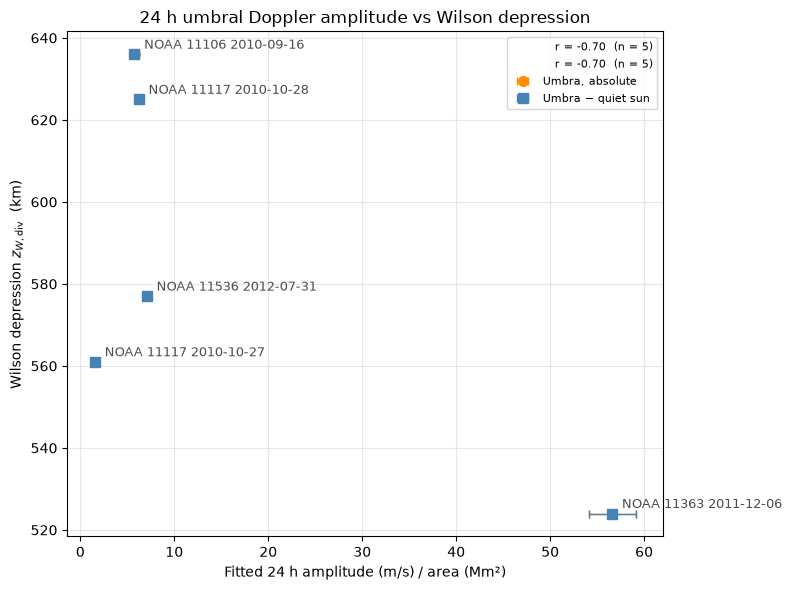

In [37]:
comparison.plot_amplitude_vs_area(fit_rows, inverse=False, save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_area(fit_rows, inverse=True, save=SAVE, plots_dir=plots_dir)
comparison.plot_amplitude_vs_depression(fit_rows, depth_key='z_div', normalize_area=True,
                                        save=SAVE, plots_dir=plots_dir)

---

# Line B — DS0N

Read from the `metrics.csv` files `03B` writes, so nothing is loaded from a cube here.

In [38]:
osc_dfs = {}
for ds in config.DS0N_IDS:
    path = config.DS0N_PROCESSED_DIR / ds / 'metrics.csv'
    if path.exists():
        osc_dfs[ds] = pd.read_csv(path)
    else:
        print(f'{ds}: no metrics.csv — run 03B first')

print(f'{len(osc_dfs)} dataset(s) loaded')
for ds, df in osc_dfs.items():
    print(f'  {ds}: {len(df)} rows, {df["time_h"].iloc[-1]:.1f} h')

10 dataset(s) loaded
  DS00: 901 rows, 180.0 h
  DS01: 1067 rows, 213.2 h
  DS02: 1076 rows, 215.0 h
  DS03: 1084 rows, 216.6 h
  DS04: 1069 rows, 213.6 h
  DS05: 1088 rows, 217.4 h
  DS06: 958 rows, 191.4 h
  DS07: 684 rows, 136.6 h
  DS08: 799 rows, 159.6 h
  DS09: 992 rows, 198.2 h


## Three amplitude estimators, compared

`max − min` is a bad amplitude estimator: it is contaminated by any surviving trend, by gaps,
and by a single outlier. It is kept here only so the newer numbers stay comparable with the
older ones.

- **`peak_to_peak`** — detrend, then half of (max − min)
- **`fft_amplitude`** — Hann window, zero-padded, coherent-gain corrected, peak searched
  inside the 16–36 h band
- **`fit_amplitude`** — a sinusoidal fit at the period the spectrum found, with a real sigma

`n_cycles` is the one to check first: below about 1.5, the window does not constrain an
amplitude no matter which estimator produced it.

In [39]:
rows = []
for ds, df in osc_dfs.items():
    window = df[(df['time_h'] >= WINDOW_H[0]) & (df['time_h'] <= WINDOW_H[1])]
    time_h = window['time_h'].to_numpy()

    for key, label in [('mean_dop_umb', 'umbra'),
                       ('mean_dop_umb_minus_quiet', 'umbra - quiet')]:
        if key == 'mean_dop_umb_minus_quiet':
            series = (window['mean_dop_umb'] - window['mean_dop_quiet']).to_numpy()
        else:
            series = window[key].to_numpy()

        summary = oscillation.amplitude_summary(time_h, series, band_h=PERIOD_BAND_H,
                                                label=f'{ds} {label}')
        rows.append({'dataset': ds, 'series': label,
                     'area_umb': float(window['area_umb'].mean()), **summary})

osc = pd.DataFrame(rows)
osc.round(2)

,dataset,series,area_umb,fft_amplitude,fft_period_h,n_cycles,fit_amplitude,fit_sigma,fit_period_h,peak_to_peak
0,DS00,umbra,1509.57,445.32,21.14,2.37,448.05,7.31,21.14,552.83
1,DS00,umbra - quiet,1509.57,3619.15,21.14,2.37,3571.29,44.10,21.14,3886.28
2,DS01,umbra,871.96,569.52,23.62,2.12,529.94,11.77,23.62,663.82
3,DS01,umbra - quiet,871.96,3566.64,23.62,2.12,3309.45,57.00,23.62,3903.24
4,DS02,umbra,2023.10,379.04,23.62,2.12,369.62,4.34,23.62,467.87
5,DS02,umbra - quiet,2023.10,2923.90,23.62,2.12,2916.23,8.47,23.62,3266.96
6,DS03,umbra,319.86,250.68,23.62,2.12,253.57,4.23,23.62,327.55
7,DS03,umbra - quiet,319.86,2533.63,23.62,2.12,2495.62,23.49,23.62,2805.29
8,DS04,umbra,596.12,448.05,23.62,2.12,445.61,6.51,23.62,556.18
9,DS04,umbra - quiet,596.12,3200.81,23.62,2.12,3204.29,10.72,23.62,3612.00


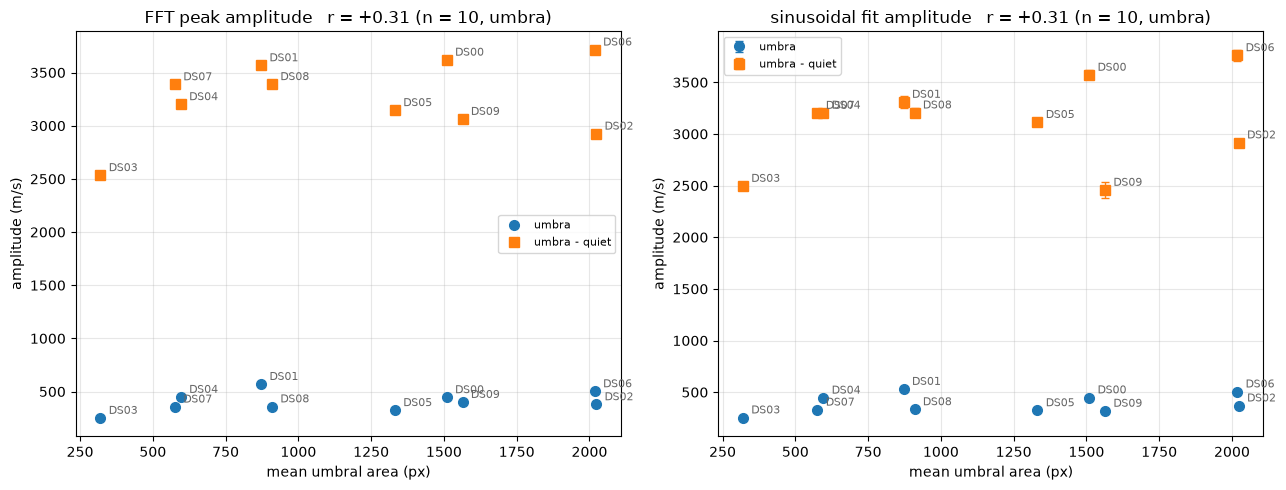

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (var, title) in zip(axes, [('fft_amplitude', 'FFT peak amplitude'),
                                   ('fit_amplitude', 'sinusoidal fit amplitude')]):
    for label, marker in [('umbra', 'o'), ('umbra - quiet', 's')]:
        sub = osc[osc['series'] == label]
        yerr = sub['fit_sigma'] if var == 'fit_amplitude' else None
        ax.errorbar(sub['area_umb'], sub[var], yerr=yerr, fmt=marker, ms=7, lw=0,
                    capsize=3, elinewidth=1, label=label)
        for _, row in sub.iterrows():
            ax.annotate(row['dataset'], (row['area_umb'], row[var]),
                        textcoords='offset points', xytext=(6, 3), fontsize=8, color='0.4')
    finite = osc[osc['series'] == 'umbra']
    ok = np.isfinite(finite['area_umb']) & np.isfinite(finite[var])
    if ok.sum() > 2:
        r = float(np.corrcoef(finite['area_umb'][ok], finite[var][ok])[0, 1])
        ax.set_title(f'{title}   r = {r:+.2f} (n = {int(ok.sum())}, umbra)')
    else:
        ax.set_title(title)
    ax.set_xlabel('mean umbral area (px)')
    ax.set_ylabel('amplitude (m/s)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Correlations

A screening tool on ten datasets: it says which pairs are worth a scatter plot, and nothing
more. Every coefficient rests on as many points as there are rows.

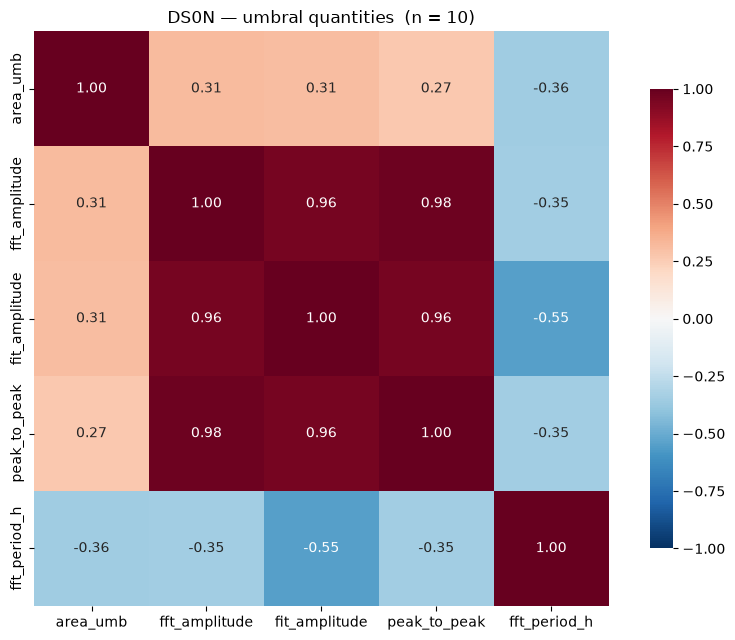

,area_umb,fft_amplitude,fit_amplitude,peak_to_peak,fft_period_h
area_umb,1.000000,0.313206,0.310767,0.266714,-0.356343
fft_amplitude,0.313206,1.000000,0.955016,0.983768,-0.350348
fit_amplitude,0.310767,0.955016,1.000000,0.958366,-0.553290
peak_to_peak,0.266714,0.983768,0.958366,1.000000,-0.348084
fft_period_h,-0.356343,-0.350348,-0.553290,-0.348084,1.000000


In [41]:
wide = osc[osc['series'] == 'umbra'].set_index('dataset')[
    ['area_umb', 'fft_amplitude', 'fit_amplitude', 'peak_to_peak', 'fft_period_h']]
comparison.correlation_heatmap(wide, title='DS0N — umbral quantities',
                               save=SAVE, plots_dir=config.DS0N_PROCESSED_DIR / 'plots')

## Spectral peaks across the datasets

`03B` writes a peak table per dataset in step 5. Pooling them shows whether the datasets
agree on which periods exist, or whether each one finds its own.

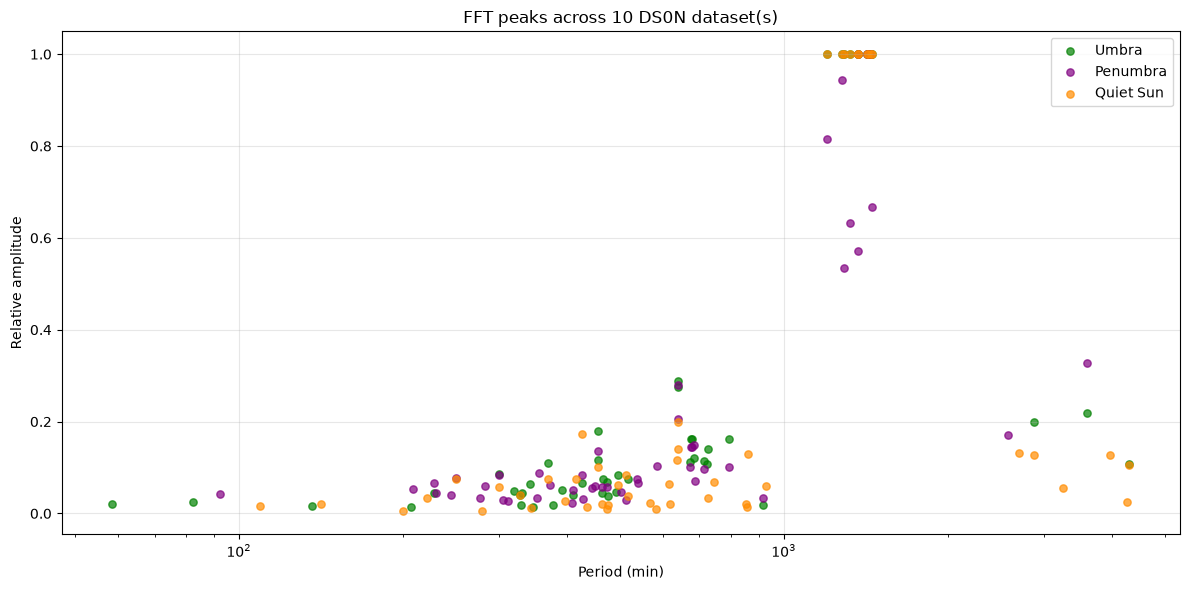

dataset    region  rank  freq_mhz  period_min  relative
   DS00     Umbra     1    0.0139      1201.3    1.0000
   DS00     Umbra     2    0.0046      3604.0    0.2185
   DS00     Umbra     3    0.0247       675.8    0.1611
   DS00     Umbra     4    0.0339       491.5    0.0467
   DS00     Umbra     5    0.0509       327.6    0.0407
   DS00  Penumbra     1    0.0139      1201.3    0.8152
   DS00  Penumbra     2    0.0046      3604.0    0.3268
   DS00  Penumbra     3    0.0247       675.8    0.1456
   DS00  Penumbra     4    0.0370       450.5    0.0591
   DS00  Penumbra     5    0.0725       230.0    0.0441
   DS00      Both     1    0.0139      1201.3    0.9078
   DS00      Both     2    0.0046      3604.0    0.3213
   DS00      Both     3    0.0247       675.8    0.1552
   DS00      Both     4    0.0370       450.5    0.0581
   DS00      Both     5    0.0725       230.0    0.0408
   DS00 Quiet Sun     1    0.0139      1201.3    1.0000
   DS00 Quiet Sun     2    0.0062      2703.0   

In [42]:
peak_frames = []
for ds in config.DS0N_IDS:
    path = config.DS0N_PROCESSED_DIR / ds / 'plots' / 'fft_peaks.csv'
    if path.exists():
        df = pd.read_csv(path)
        # Peak tables written before the spectra merge call the column `rel_amplitude`;
        # `spectra.save_peak_table` now writes `relative`, because the same table also
        # holds relative *power* when the spectrum is a PSD. Accept either, so files
        # already on disk stay readable without re-running 03B.
        if 'relative' not in df.columns and 'rel_amplitude' in df.columns:
            df = df.rename(columns={'rel_amplitude': 'relative'})
        df.insert(0, 'dataset', ds)
        peak_frames.append(df)

if peak_frames:
    peaks = pd.concat(peak_frames, ignore_index=True)
    fig, ax = plt.subplots(figsize=(12, 6))
    for region, colour in [('Umbra', 'green'), ('Penumbra', 'purple'),
                           ('Quiet Sun', 'darkorange')]:
        sub = peaks[peaks['region'] == region]
        ax.scatter(sub['period_min'], sub['relative'], s=28, alpha=0.7,
                   color=colour, label=region)
    ax.set_xscale('log')
    ax.set_xlabel('Period (min)')
    ax.set_ylabel('Relative amplitude')
    ax.set_title(f'FFT peaks across {peaks["dataset"].nunique()} DS0N dataset(s)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(peaks.head(20).to_string(index=False))
else:
    print('No fft_peaks.csv found — run 03B step 5 with SAVE = True first.')

---

## Where this leaves things

- The umbra and the penumbra move differently from the quiet sun, but the quiet sun's own
  24 h signal is large enough that the *absolute* umbral amplitude is not a measurement of
  the sunspot. The `umbra − quiet` column is the one to quote.
- That the quiet-sun oscillation comes out in antiphase suggests the cleaning removed more
  than it should have. Subtracting the quiet-sun cube from the region cubes directly, rather
  than subtracting per-frame means, would give relative velocities and is the obvious next
  step.
- The magnetogram residual and the Doppler signal share a period. Whether they are genuinely
  in phase, and whether that survives the μ (geometry) check in step 7 of `03A`/`03B`, is
  still open — see `03T_analysis_sandbox.ipynb`.